In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [140]:
#load the dataset
df=pd.read_csv("london_houses.csv")

EDA

In [141]:
df.shape

(1000, 17)

In [142]:
df.head()

,Address,Neighborhood,Bedrooms,Bathrooms,Square Meters,Building Age,Garden,Garage,Floors,Property Type,Heating Type,Balcony,Interior Style,View,Materials,Building Status,Price (£)
0,78 Regent Street,Notting Hill,2,3,179,72,No,No,3,Semi-Detached,Electric Heating,High-level Balcony,Industrial,Garden,Marble,Renovated,2291200
1,198 Oxford Street,Westminster,2,1,123,34,Yes,No,1,Apartment,Central Heating,High-level Balcony,Industrial,City,Laminate Flooring,Old,1476000
2,18 Regent Street,Soho,5,3,168,38,No,Yes,3,Semi-Detached,Central Heating,No Balcony,Industrial,Street,Wood,Renovated,1881600
3,39 Piccadilly Circus,Islington,5,1,237,53,Yes,Yes,1,Apartment,Underfloor Heating,No Balcony,Classic,Park,Granite,Renovated,1896000
4,116 Fleet Street,Marylebone,4,1,127,23,No,Yes,2,Semi-Detached,Central Heating,No Balcony,Modern,Park,Wood,Old,1524000


In [143]:
df.describe()

,Bedrooms,Bathrooms,Square Meters,Building Age,Floors,Price (£)
count,1000.000000,1000.000000,1000.0000,1000.00000,1000.000000,1.000000e+03
mean,3.013000,2.003000,149.6270,49.96500,1.991000,1.840807e+06
std,1.393834,0.808483,58.0562,29.07086,0.821946,8.793484e+05
min,1.000000,1.000000,50.0000,1.00000,1.000000,3.866660e+05
25%,2.000000,1.000000,99.0000,24.00000,1.000000,1.161400e+06
50%,3.000000,2.000000,148.0000,50.00000,2.000000,1.721999e+06
75%,4.000000,3.000000,201.0000,76.00000,3.000000,2.390500e+06
max,5.000000,3.000000,249.0000,99.00000,3.000000,4.980000e+06


In [144]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Address          1000 non-null   object
 1   Neighborhood     1000 non-null   object
 2   Bedrooms         1000 non-null   int64 
 3   Bathrooms        1000 non-null   int64 
 4   Square Meters    1000 non-null   int64 
 5   Building Age     1000 non-null   int64 
 6   Garden           1000 non-null   object
 7   Garage           1000 non-null   object
 8   Floors           1000 non-null   int64 
 9   Property Type    1000 non-null   object
 10  Heating Type     1000 non-null   object
 11  Balcony          1000 non-null   object
 12  Interior Style   1000 non-null   object
 13  View             1000 non-null   object
 14  Materials        1000 non-null   object
 15  Building Status  1000 non-null   object
 16  Price (£)        1000 non-null   int64 
dtypes: int64(6), object(11)
memory usa

In [145]:
#let drop the duplicates columns
df.drop_duplicates(inplace=True)

In [146]:
df.shape

(1000, 17)

In [147]:
df.isnull().sum()

Address            0
Neighborhood       0
Bedrooms           0
Bathrooms          0
Square Meters      0
Building Age       0
Garden             0
Garage             0
Floors             0
Property Type      0
Heating Type       0
Balcony            0
Interior Style     0
View               0
Materials          0
Building Status    0
Price (£)          0
dtype: int64

In [148]:
df.dtypes

Address            object
Neighborhood       object
Bedrooms            int64
Bathrooms           int64
Square Meters       int64
Building Age        int64
Garden             object
Garage             object
Floors              int64
Property Type      object
Heating Type       object
Balcony            object
Interior Style     object
View               object
Materials          object
Building Status    object
Price (£)           int64
dtype: object

In [149]:
df.sample()

,Address,Neighborhood,Bedrooms,Bathrooms,Square Meters,Building Age,Garden,Garage,Floors,Property Type,Heating Type,Balcony,Interior Style,View,Materials,Building Status,Price (£)
449,41 Regent Street,Shoreditch,1,3,216,83,No,Yes,2,Apartment,Central Heating,No Balcony,Classic,Garden,Marble,Renovated,1584000


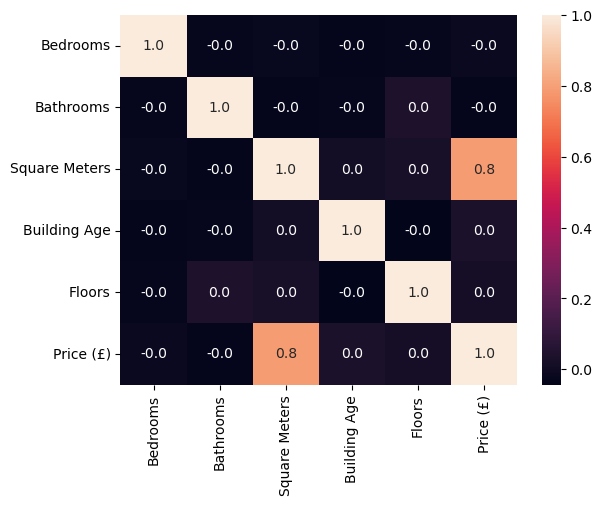

In [150]:
#let check the correlation....

sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".1f")
plt.show()

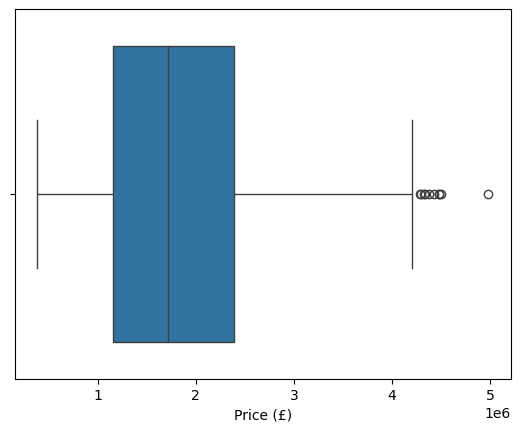

In [151]:
sns.boxplot(x=df['Price (£)'])
plt.show()

In [152]:
df['Neighborhood'].value_counts()

Neighborhood
Kensington      114
Marylebone      113
Camden          106
Westminster      98
Greenwich        97
Islington        97
Notting Hill     96
Soho             96
Chelsea          94
Shoreditch       89
Name: count, dtype: int64

Neighborhood
Chelsea         2485333.0
Westminster     2248200.0
Kensington      2234400.0
Marylebone      1875000.0
Notting Hill    1874666.5
Soho            1702400.0
Camden          1676999.0
Islington       1452000.0
Shoreditch      1290666.0
Greenwich       1248000.0
Name: Price (£), dtype: float64


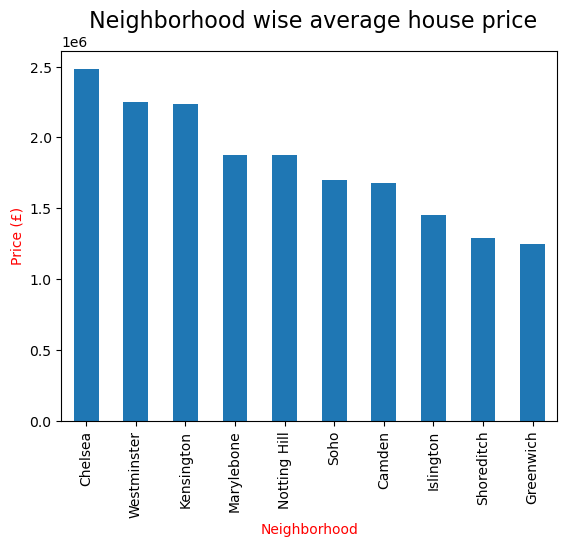

In [153]:
#let find the Neighborhood wise average house price.....

v1=df.groupby('Neighborhood')['Price (£)'].median().sort_values(ascending=False)
print(v1)
v1.plot(kind='bar')
plt.title(" Neighborhood wise average house price",fontsize=16,color='black')
plt.xlabel("Neighborhood",fontsize=10,color='r')
plt.ylabel("Price (£)",fontsize=10,color='r')
plt.show()

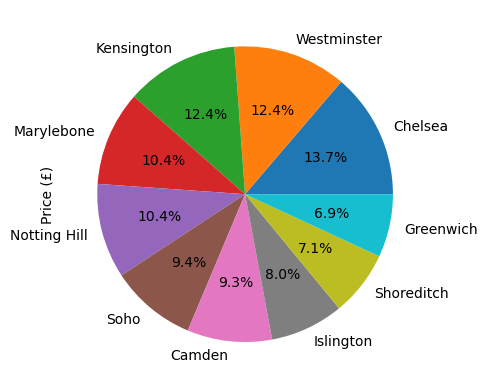

In [154]:
#let find the Neighborhood wise average house price.......pie chart


v1.plot(kind='pie',autopct="%1.1f%%")

plt.show()

In [155]:
df.columns

Index(['Address', 'Neighborhood', 'Bedrooms', 'Bathrooms', 'Square Meters',
       'Building Age', 'Garden', 'Garage', 'Floors', 'Property Type',
       'Heating Type', 'Balcony', 'Interior Style', 'View', 'Materials',
       'Building Status', 'Price (£)'],
      dtype='object')

Bedrooms
2    1835199.0
4    1742000.0
3    1736000.0
5    1664333.0
1    1618000.0
Name: Price (£), dtype: float64


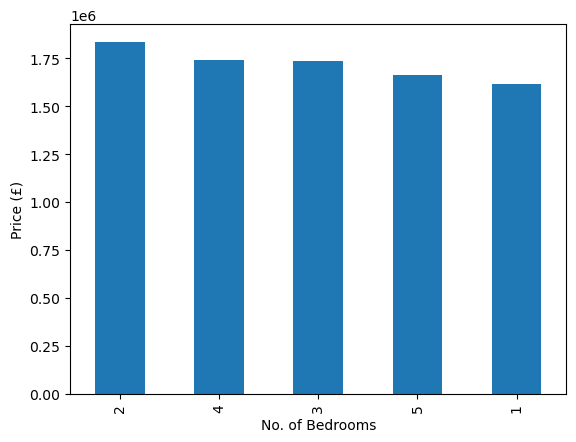

In [156]:
#bedroom wise price....

v2=df.groupby('Bedrooms')['Price (£)'].median().sort_values(ascending=False)
print(v2)

v2.plot(kind="bar")
plt.xlabel("No. of Bedrooms")
plt.ylabel("Price (£)")
plt.show()

In [157]:
df['Property Type'].value_counts()

Property Type
Detached House    349
Semi-Detached     345
Apartment         306
Name: count, dtype: int64

Property Type
Detached House    2128000.0
Semi-Detached     1766400.0
Apartment         1401666.5
Name: Price (£), dtype: float64


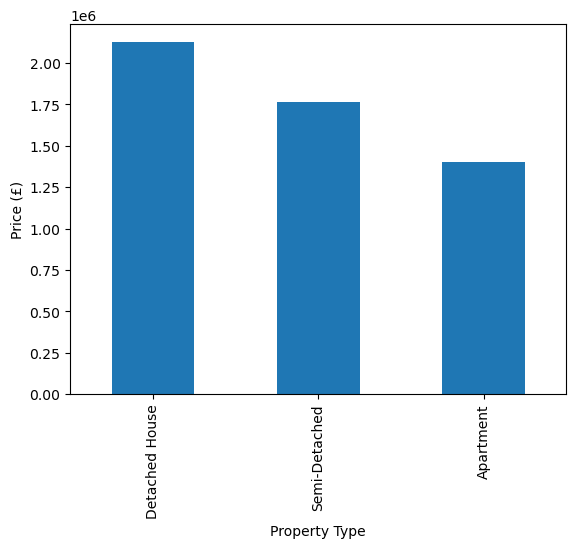

In [158]:
#Property Type wise average price......

v3=df.groupby('Property Type')['Price (£)'].median().sort_values(ascending=False)
print(v3)
v3.plot(kind="bar")
plt.xlabel("Property Type")
plt.ylabel("Price (£)")
plt.show()

Data Preprocessing.....

In [159]:
df.columns

Index(['Address', 'Neighborhood', 'Bedrooms', 'Bathrooms', 'Square Meters',
       'Building Age', 'Garden', 'Garage', 'Floors', 'Property Type',
       'Heating Type', 'Balcony', 'Interior Style', 'View', 'Materials',
       'Building Status', 'Price (£)'],
      dtype='object')

In [160]:
df.dtypes

Address            object
Neighborhood       object
Bedrooms            int64
Bathrooms           int64
Square Meters       int64
Building Age        int64
Garden             object
Garage             object
Floors              int64
Property Type      object
Heating Type       object
Balcony            object
Interior Style     object
View               object
Materials          object
Building Status    object
Price (£)           int64
dtype: object

In [161]:
#let drop the address column

df.drop("Address",axis=1,inplace=True)

In [162]:
df=pd.get_dummies(df,columns=["Neighborhood"],dtype=int)

In [163]:
df.columns

Index(['Bedrooms', 'Bathrooms', 'Square Meters', 'Building Age', 'Garden',
       'Garage', 'Floors', 'Property Type', 'Heating Type', 'Balcony',
       'Interior Style', 'View', 'Materials', 'Building Status', 'Price (£)',
       'Neighborhood_Camden', 'Neighborhood_Chelsea', 'Neighborhood_Greenwich',
       'Neighborhood_Islington', 'Neighborhood_Kensington',
       'Neighborhood_Marylebone', 'Neighborhood_Notting Hill',
       'Neighborhood_Shoreditch', 'Neighborhood_Soho',
       'Neighborhood_Westminster'],
      dtype='object')

In [164]:
df.dtypes

Bedrooms                      int64
Bathrooms                     int64
Square Meters                 int64
Building Age                  int64
Garden                       object
Garage                       object
Floors                        int64
Property Type                object
Heating Type                 object
Balcony                      object
Interior Style               object
View                         object
Materials                    object
Building Status              object
Price (£)                     int64
Neighborhood_Camden           int64
Neighborhood_Chelsea          int64
Neighborhood_Greenwich        int64
Neighborhood_Islington        int64
Neighborhood_Kensington       int64
Neighborhood_Marylebone       int64
Neighborhood_Notting Hill     int64
Neighborhood_Shoreditch       int64
Neighborhood_Soho             int64
Neighborhood_Westminster      int64
dtype: object

In [165]:
df["Garden"].value_counts()

Garden
Yes    512
No     488
Name: count, dtype: int64

In [166]:
df["Garden"]=df["Garden"].map({"Yes":1,"No":0})

In [167]:
df["Garden"].value_counts()

Garden
1    512
0    488
Name: count, dtype: int64

In [168]:
df["Garage"].value_counts()

Garage
Yes    501
No     499
Name: count, dtype: int64

In [169]:
df["Garage"]=df["Garage"].map({"Yes":1,"No":0})

In [170]:
df["Garage"].value_counts()

Garage
1    501
0    499
Name: count, dtype: int64

In [171]:
df.sample()

,Bedrooms,Bathrooms,Square Meters,Building Age,Garden,Garage,Floors,Property Type,Heating Type,Balcony,...,Neighborhood_Camden,Neighborhood_Chelsea,Neighborhood_Greenwich,Neighborhood_Islington,Neighborhood_Kensington,Neighborhood_Marylebone,Neighborhood_Notting Hill,Neighborhood_Shoreditch,Neighborhood_Soho,Neighborhood_Westminster
250,1,1,101,71,0,0,1,Apartment,Central Heating,Low-level Balcony,...,1,0,0,0,0,0,0,0,0,0


In [172]:
c1=["Property Type","Heating Type","Balcony","Interior Style","View","Materials","Building Status"]

for i in c1:
    print(df[i].value_counts())
    print()
    print()
    print("--------------------")

Property Type
Detached House    349
Semi-Detached     345
Apartment         306
Name: count, dtype: int64


--------------------
Heating Type
Electric Heating      266
Gas Heating           255
Underfloor Heating    243
Central Heating       236
Name: count, dtype: int64


--------------------
Balcony
No Balcony            340
High-level Balcony    331
Low-level Balcony     329
Name: count, dtype: int64


--------------------
Interior Style
Classic       263
Industrial    260
Modern        243
Minimalist    234
Name: count, dtype: int64


--------------------
View
Sea       210
Garden    206
Park      204
City      196
Street    184
Name: count, dtype: int64


--------------------
Materials
Wood                 264
Laminate Flooring    258
Marble               243
Granite              235
Name: count, dtype: int64


--------------------
Building Status
Renovated    341
New          332
Old          327
Name: count, dtype: int64


--------------------


In [173]:
df=pd.get_dummies(df,columns=["Property Type","Heating Type","Balcony","Interior Style","View","Materials","Building Status"],dtype=int)

In [174]:
df.columns

Index(['Bedrooms', 'Bathrooms', 'Square Meters', 'Building Age', 'Garden',
       'Garage', 'Floors', 'Price (£)', 'Neighborhood_Camden',
       'Neighborhood_Chelsea', 'Neighborhood_Greenwich',
       'Neighborhood_Islington', 'Neighborhood_Kensington',
       'Neighborhood_Marylebone', 'Neighborhood_Notting Hill',
       'Neighborhood_Shoreditch', 'Neighborhood_Soho',
       'Neighborhood_Westminster', 'Property Type_Apartment',
       'Property Type_Detached House', 'Property Type_Semi-Detached',
       'Heating Type_Central Heating', 'Heating Type_Electric Heating',
       'Heating Type_Gas Heating', 'Heating Type_Underfloor Heating',
       'Balcony_High-level Balcony', 'Balcony_Low-level Balcony',
       'Balcony_No Balcony', 'Interior Style_Classic',
       'Interior Style_Industrial', 'Interior Style_Minimalist',
       'Interior Style_Modern', 'View_City', 'View_Garden', 'View_Park',
       'View_Sea', 'View_Street', 'Materials_Granite',
       'Materials_Laminate Flooring', '

In [175]:
df.dtypes

Bedrooms                           int64
Bathrooms                          int64
Square Meters                      int64
Building Age                       int64
Garden                             int64
Garage                             int64
Floors                             int64
Price (£)                          int64
Neighborhood_Camden                int64
Neighborhood_Chelsea               int64
Neighborhood_Greenwich             int64
Neighborhood_Islington             int64
Neighborhood_Kensington            int64
Neighborhood_Marylebone            int64
Neighborhood_Notting Hill          int64
Neighborhood_Shoreditch            int64
Neighborhood_Soho                  int64
Neighborhood_Westminster           int64
Property Type_Apartment            int64
Property Type_Detached House       int64
Property Type_Semi-Detached        int64
Heating Type_Central Heating       int64
Heating Type_Electric Heating      int64
Heating Type_Gas Heating           int64
Heating Type_Und

In [176]:
df.shape

(1000, 44)

In [177]:
df.isnull().sum()

Bedrooms                           0
Bathrooms                          0
Square Meters                      0
Building Age                       0
Garden                             0
Garage                             0
Floors                             0
Price (£)                          0
Neighborhood_Camden                0
Neighborhood_Chelsea               0
Neighborhood_Greenwich             0
Neighborhood_Islington             0
Neighborhood_Kensington            0
Neighborhood_Marylebone            0
Neighborhood_Notting Hill          0
Neighborhood_Shoreditch            0
Neighborhood_Soho                  0
Neighborhood_Westminster           0
Property Type_Apartment            0
Property Type_Detached House       0
Property Type_Semi-Detached        0
Heating Type_Central Heating       0
Heating Type_Electric Heating      0
Heating Type_Gas Heating           0
Heating Type_Underfloor Heating    0
Balcony_High-level Balcony         0
Balcony_Low-level Balcony          0
B

In [178]:
X=df.drop("Price (£)",axis=1)
y=df["Price (£)"]

In [179]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [180]:
X_train.shape

(800, 43)

In [181]:
X_test.shape

(200, 43)

In [186]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

model1 = RandomForestRegressor(n_estimators=200,max_depth=15, random_state=42)

model1.fit(X_train, y_train)

y_p1 = model1.predict(X_test)

print("mean squared_error:-",mean_squared_error(y_test,y_p1))
print("mean_absolute_error:-",mean_absolute_error(y_test,y_p1))
print("r2_score:-",r2_score(y_test,y_p1))

mean squared_error:- 29181550115.091904
mean_absolute_error:- 128408.15715063504
r2_score:- 0.9637744730291861


In [187]:
#varify the model will become overfitting or underfitting

print("Train Score:", model1.score(X_train, y_train))
print("Test Score :", model1.score(X_test, y_test))

Train Score: 0.9956373956375973
Test Score : 0.9637744730291861


In [189]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model1.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

print(importance.head(10))

                         Feature  Importance
2                  Square Meters    0.660017
18  Property Type_Detached House    0.076508
8           Neighborhood_Chelsea    0.048920
9         Neighborhood_Greenwich    0.040439
11       Neighborhood_Kensington    0.039488
17       Property Type_Apartment    0.028068
16      Neighborhood_Westminster    0.025786
14       Neighborhood_Shoreditch    0.012430
19   Property Type_Semi-Detached    0.009539
13     Neighborhood_Notting Hill    0.007424


In [191]:
#here we can see that error margine rate is very low near by 6 to 7 percent.....
df["Price (£)"].mean()

np.float64(1840807.278)

In [192]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [194]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)
X_train_scaled

,Bedrooms,Bathrooms,Square Meters,Building Age,Garden,Garage,Floors,Neighborhood_Camden,Neighborhood_Chelsea,Neighborhood_Greenwich,...,View_Park,View_Sea,View_Street,Materials_Granite,Materials_Laminate Flooring,Materials_Marble,Materials_Wood,Building Status_New,Building Status_Old,Building Status_Renovated
29,0.726293,0.004665,-0.385173,0.277605,-1.030464,-0.990050,-1.188945,-0.340235,-0.319262,-0.335643,...,-0.498046,-0.519462,2.073165,-0.561951,1.749547,-0.583124,-0.592749,1.420869,-0.695866,-0.721743
535,-1.428346,1.248619,0.877477,0.345687,-1.030464,-0.990050,1.219045,-0.340235,-0.319262,2.979353,...,-0.498046,1.925067,-0.482354,1.779513,-0.571577,-0.583124,-0.592749,-0.703795,-0.695866,1.385535
695,0.726293,-1.239290,0.756401,1.060549,-1.030464,1.010051,-1.188945,-0.340235,-0.319262,2.979353,...,-0.498046,1.925067,-0.482354,-0.561951,-0.571577,1.714901,-0.592749,-0.703795,1.437057,-0.721743
557,0.726293,0.004665,0.963960,-0.335134,-1.030464,1.010051,-1.188945,-0.340235,-0.319262,-0.335643,...,-0.498046,1.925067,-0.482354,-0.561951,-0.571577,-0.583124,1.687055,-0.703795,-0.695866,1.385535
836,0.008080,-1.239290,0.306690,0.515892,-1.030464,1.010051,-1.188945,-0.340235,-0.319262,-0.335643,...,-0.498046,-0.519462,-0.482354,-0.561951,-0.571577,-0.583124,1.687055,-0.703795,1.437057,-0.721743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,-0.710133,1.248619,-1.578637,-0.130888,0.970437,-0.990050,-1.188945,-0.340235,-0.319262,2.979353,...,2.007846,-0.519462,-0.482354,-0.561951,-0.571577,-0.583124,1.687055,-0.703795,-0.695866,1.385535
270,1.444506,0.004665,-0.523546,0.856303,-1.030464,1.010051,0.015050,-0.340235,-0.319262,-0.335643,...,-0.498046,1.925067,-0.482354,-0.561951,-0.571577,1.714901,-0.592749,1.420869,-0.695866,-0.721743
860,-1.428346,-1.239290,-1.457561,0.175482,-1.030464,1.010051,-1.188945,-0.340235,-0.319262,-0.335643,...,-0.498046,-0.519462,-0.482354,-0.561951,-0.571577,1.714901,-0.592749,-0.703795,1.437057,-0.721743
435,-1.428346,0.004665,-1.682416,-1.560613,-1.030464,-0.990050,1.219045,-0.340235,-0.319262,-0.335643,...,-0.498046,-0.519462,2.073165,-0.561951,-0.571577,1.714901,-0.592749,-0.703795,-0.695866,1.385535


In [197]:
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)
X_test_scaled

,Bedrooms,Bathrooms,Square Meters,Building Age,Garden,Garage,Floors,Neighborhood_Camden,Neighborhood_Chelsea,Neighborhood_Greenwich,...,View_Park,View_Sea,View_Street,Materials_Granite,Materials_Laminate Flooring,Materials_Marble,Materials_Wood,Building Status_New,Building Status_Old,Building Status_Renovated
521,0.726293,1.248619,1.033146,1.060549,0.970437,-0.990050,-1.188945,-0.340235,3.132221,-0.335643,...,-0.498046,1.925067,-0.482354,1.779513,-0.571577,-0.583124,-0.592749,-0.703795,-0.695866,1.385535
737,1.444506,0.004665,-1.180816,-0.062806,0.970437,1.010051,-1.188945,2.939142,-0.319262,-0.335643,...,-0.498046,-0.519462,-0.482354,1.779513,-0.571577,-0.583124,-0.592749,-0.703795,-0.695866,1.385535
740,1.444506,1.248619,-0.523546,0.413769,-1.030464,-0.990050,0.015050,-0.340235,-0.319262,-0.335643,...,2.007846,-0.519462,-0.482354,-0.561951,1.749547,-0.583124,-0.592749,-0.703795,1.437057,-0.721743
660,-1.428346,1.248619,-1.474857,-0.913832,-1.030464,1.010051,0.015050,-0.340235,-0.319262,-0.335643,...,-0.498046,1.925067,-0.482354,1.779513,-0.571577,-0.583124,-0.592749,-0.703795,1.437057,-0.721743
411,-0.710133,1.248619,0.393173,-1.696777,0.970437,-0.990050,0.015050,-0.340235,-0.319262,-0.335643,...,-0.498046,-0.519462,2.073165,1.779513,-0.571577,-0.583124,-0.592749,-0.703795,-0.695866,1.385535
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,0.726293,0.004665,0.687215,-0.539381,0.970437,-0.990050,1.219045,-0.340235,-0.319262,2.979353,...,-0.498046,-0.519462,2.073165,-0.561951,1.749547,-0.583124,-0.592749,1.420869,-0.695866,-0.721743
332,-0.710133,0.004665,1.673119,1.332878,0.970437,-0.990050,-1.188945,2.939142,-0.319262,-0.335643,...,-0.498046,-0.519462,-0.482354,-0.561951,1.749547,-0.583124,-0.592749,1.420869,-0.695866,-0.721743
208,0.008080,1.248619,0.237504,1.060549,0.970437,1.010051,0.015050,2.939142,-0.319262,-0.335643,...,-0.498046,1.925067,-0.482354,-0.561951,-0.571577,-0.583124,1.687055,1.420869,-0.695866,-0.721743
613,0.726293,0.004665,-0.990553,0.209523,0.970437,-0.990050,-1.188945,-0.340235,-0.319262,-0.335643,...,2.007846,-0.519462,-0.482354,-0.561951,1.749547,-0.583124,-0.592749,1.420869,-0.695866,-0.721743


In [199]:
from sklearn.linear_model import LinearRegression

m2=LinearRegression()

m2.fit(X_train_scaled,y_train)

y_p2=m2.predict(X_test_scaled)

print("mean squared_error:-",mean_squared_error(y_test,y_p2))
print("mean_absolute_error:-",mean_absolute_error(y_test,y_p2))
print("r2_score:-",r2_score(y_test,y_p2))

mean squared_error:- 46319943795.7099
mean_absolute_error:- 158707.03962582396
r2_score:- 0.9424991350137265


In [201]:
#ridge algorithm

from sklearn.linear_model import Ridge

m3=Ridge(alpha=1.0)

m3.fit(X_train_scaled,y_train)

y_p3=m3.predict(X_test_scaled)

print("mean squared_error:-",mean_squared_error(y_test,y_p3))
print("mean_absolute_error:-",mean_absolute_error(y_test,y_p3))
print("r2_score:-",r2_score(y_test,y_p3))

mean squared_error:- 46325819487.17233
mean_absolute_error:- 158603.01577776606
r2_score:- 0.9424918410208198
